# **Team 9 - Machine Learning Project**
##Team Member:
- Member 1: PIYUMI HETTIARACHCHIGE DONA (105269437)
- Member 2: Barsa Rana (105203163)
- Member 3: Duc Ha (103492558)
- Member 4: Nishok Periyanaickenpalayam Jothivenkat (105069598)
- Member 5: Tarun Maravanigee Ganesha Prasad (105323346)
- Member 6: Keyur Sandipbhai Patel (105196195)

|                                         |                                                                                                       |                                                                                                                                                                                                                                                                                         |                        |        |
|-----------------------------------------|-------------------------------------------------------------------------------------------------------|-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|------------------------|--------|
| Members                                 | Task 1                                                                                                | Task 2                                                                                                                                                                                                                                                                                  | Task 3                 | Others |
| NISHOK PERIYANAICKENPALAYAM JOTHIVENKAT | Data pre-processing and exploratory data analysis (EDA): class distribution, sample image grid, augmentation visualisation and data split verification for Task 1                                                                                                        |                                                                                                                                                                                                                                                                                         | Compile all comparison |        |
| Barsa Rana                              |Implemented the full train-from-scratch deep learning solution and compared its performance with a pretrained model due to lower accuracy. The train-from-scratch implementation was used for analysis and comparison with pretrained model and was not included in the final solution.                                                                                                       |  |                        |        |
| PIYUMI HETTIARACHCHIGE DONA             |                                                                                                       | Implemented a Machine Learning solution for CIFAR-10 image classification, including feature engineering, feature extraction comparison, Linear SVM model development, hyperparameter tuning (C), model training and evaluation, confusion matrix analysis, classification report generation, per-class accuracy evaluation, prediction visualisation, and performance analysis. This implementation was used for analysis and comparison of feature extraction methods. A higher-accuracy model was selected for the final solution, therefore this implementation was not included in the final submission.                                                                                                                                                                                                                                                 |                        |        |
| Tarun Maravanigee Ganesha Prasad        | Implemented the primary deep learning model: loaded a pretrained ResNet-18 (ImageNet weights, not CIFAR-trained) and finetuned it on CIFAR-10, achieving 94.16% test accuracy; built the training pipeline and completed the full performance assessment — test accuracy, confusion matrix, training loss curve, and sample predictions. |                                                                                                                                                                                                                                                                                         |                        |        |
| Keyur Sandipbhai Patel                  |                                                                                                       | Implemented the complete Machine Learning solution for CIFAR-10 image classification. This included feature engineering using HOG, HSV Colour Histogram, and LBP, PCA dimensionality reduction, RBF SVM model development, hyperparameter tuning (C), model training and evaluation, confusion matrix analysis, classification report generation, per-class accuracy evaluation, sample prediction visualisation, and preparation of results for Deep Learning vs Machine Learning comparison.                                                                                                                                                            |                        |        |
| Duc Ha                                  | Review, reconfigure and organize the notebook for standard pipeline. Setup the task framework: configure filepath, libraries and hardware                                           | Review, reconfigure and organize the notebook for standard pipeline. Setup the task framework: configure filepath, libraries and hardware                                                                                                                                                                                                                             |                        |        |

#Task 1 Deep Learning

##Importing libraries

In [ ]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

The previous error `FileNotFoundError: [Errno 2] No such file or directory: 'data_batch_1'` indicates that the CIFAR-10 dataset is not present in the environment. Let's download and extract it.

##Download and extract the dataset

In [ ]:

!wget https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz


!tar -xf cifar-10-python.tar.gz


import os
os.chdir('cifar-10-batches-py')

In [ ]:
import pickle

def unpickle(file):
    with open(file, 'rb') as fo:
        return pickle.load(fo, encoding='bytes')

# 5 training batches -> 50,000 images
xs, ys = [], []
for i in range(1, 6):
    b = unpickle(f'data_batch_{i}')
    xs.append(b[b'data'])
    ys += b[b'labels']
X_train_full = np.concatenate(xs).reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)  # (50000,32,32,3) uint8
y_train_full = np.array(ys)

# official test batch -> 10,000 images
t = unpickle('test_batch')
X_test = t[b'data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
y_test = np.array(t[b'labels'])

classes = [n.decode() for n in unpickle('batches.meta')[b'label_names']]
print('train', X_train_full.shape, 'test', X_test.shape)
print(classes)

##Splitting training and validation datasets

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

SEED = 42



splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=SEED)
train_idx, val_idx = next(splitter.split(np.zeros(len(y_train_full)), y_train_full))


np.save('train_idx.npy', train_idx)
np.save('val_idx.npy', val_idx)

print('train', len(train_idx), 'val', len(val_idx))
print('val class balance', np.bincount(y_train_full[val_idx]))

##Data loading training, validation and test set

In [ ]:
from PIL import Image

# ResNet expects 224x224 + ImageNet normalization
train_tf = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),                 # light augmentation
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
eval_tf = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class CIFAR10Set(Dataset):
    def __init__(self, images, labels, transform):
        self.images, self.labels, self.transform = images, labels, transform
    def __len__(self):
        return len(self.images)
    def __getitem__(self, i):
        img = Image.fromarray(self.images[i])          # uint8 HWC -> PIL
        return self.transform(img), int(self.labels[i])

train_set = CIFAR10Set(X_train_full[train_idx], y_train_full[train_idx], train_tf)
val_set   = CIFAR10Set(X_train_full[val_idx],   y_train_full[val_idx],   eval_tf)
test_set  = CIFAR10Set(X_test, y_test, eval_tf)

# num_workers=0 avoids Windows/Jupyter multiprocessing issues; bump to 2 if it runs fine
train_loader = DataLoader(train_set, batch_size=64, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=64, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=64, shuffle=False, num_workers=0, pin_memory=True)
print('batches:', len(train_loader), len(val_loader), len(test_loader))

##Traininng model

In [ ]:
from torchvision.models import resnet18, ResNet18_Weights

# ImageNet weights — NOT trained on CIFAR-10, so allowed by the assignment
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 10)   # 1000 ImageNet classes -> 10 CIFAR classes
model = model.to(device)
print('final layer:', model.fc)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
EPOCHS = 5

def accuracy(loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs).argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

train_losses = []
for epoch in range(EPOCHS):
    model.train()
    running = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        running += loss.item()
    avg = running / len(train_loader)
    train_losses.append(avg)
    print(f'epoch {epoch+1}/{EPOCHS}  train_loss {avg:.4f}  val_acc {accuracy(val_loader):.4f}')

epoch 1/5  train_loss 0.3354  val_acc 0.9348
epoch 2/5  train_loss 0.1390  val_acc 0.9416
epoch 3/5  train_loss 0.0850  val_acc 0.9418
epoch 4/5  train_loss 0.0671  val_acc 0.9402
epoch 5/5  train_loss 0.0454  val_acc 0.9466


In [ ]:
torch.save(model.state_dict(), 'resnet18_cifar10.pth')
print('saved resnet18_cifar10.pth')

saved resnet18_cifar10.pth


##Evaluating metrics

TEST accuracy: 0.9476


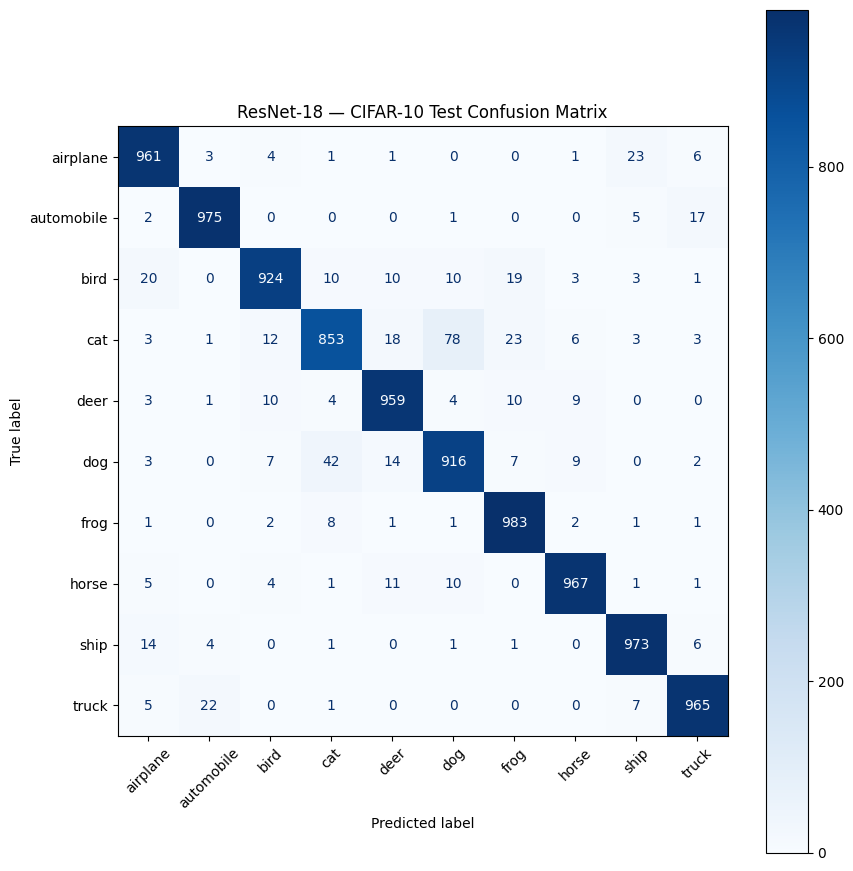

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = (all_preds == all_labels).mean()
print(f'TEST accuracy: {test_acc:.4f}')

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(9, 9))
ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=ax, xticks_rotation=45, cmap='Blues')
plt.title('ResNet-18 — CIFAR-10 Test Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

# Per-class precision, recall, and F1-score on the test set.
# Uses all_labels and all_preds collected in the evaluation cell.
report = classification_report(
    all_labels, all_preds,
    target_names=classes,        # use the CIFAR-10 class names as row labels
    digits=4,                    # show 4 decimal places
    output_dict=True             # return as a dict so we can display it as a table
)

# Convert to a clean DataFrame and show per-class rows + averages.
report_df = pd.DataFrame(report).transpose()
report_df = report_df.round(4)
display(report_df)

,precision,recall,f1-score,support
airplane,0.9449,0.9610,0.9529,1000.0000
automobile,0.9692,0.9750,0.9721,1000.0000
bird,0.9595,0.9240,0.9414,1000.0000
cat,0.9262,0.8530,0.8881,1000.0000
deer,0.9458,0.9590,0.9523,1000.0000
dog,0.8972,0.9160,0.9065,1000.0000
frog,0.9425,0.9830,0.9623,1000.0000
horse,0.9699,0.9670,0.9685,1000.0000
ship,0.9577,0.9730,0.9653,1000.0000
truck,0.9631,0.9650,0.9640,1000.0000


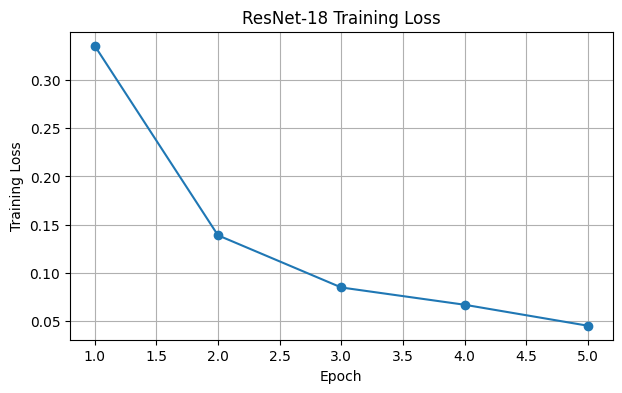

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, EPOCHS + 1), train_losses, marker='o')
plt.xlabel('Epoch'); plt.ylabel('Training Loss')
plt.title('ResNet-18 Training Loss')
plt.grid(True); plt.show()

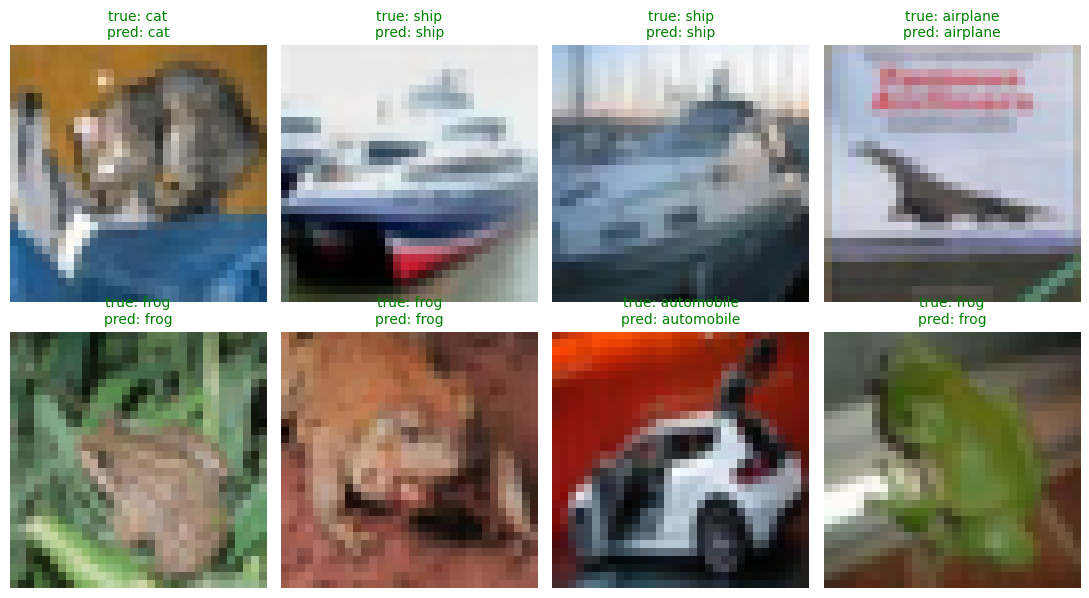

In [ ]:
# raw (un-normalized) images for display + matching labels from the test set
inv_idx = np.arange(8)
imgs_disp = X_test[inv_idx]                      # uint8 32x32x3, for showing
batch = torch.stack([eval_tf(Image.fromarray(im)) for im in imgs_disp]).to(device)

model.eval()
with torch.no_grad():
    pred = model(batch).argmax(1).cpu().numpy()

fig, axes = plt.subplots(2, 4, figsize=(11, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs_disp[i])
    true_c, pred_c = classes[y_test[inv_idx[i]]], classes[pred[i]]
    color = 'green' if true_c == pred_c else 'red'
    ax.set_title(f'true: {true_c}\npred: {pred_c}', color=color, fontsize=10)
    ax.axis('off')
plt.tight_layout(); plt.show()